看了一下 TrajNet++ 中的数据，似乎只经过了放缩，未经过仿射变换

In [1]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: /data6/yuzihan/WorkSpace/35-HuaweiCrowdSimulation/HuaweiCrowdSimulationCode


In [7]:
import pandas as pd

df_trajnet = pd.read_json('./playground/test.jsonl', lines=True)
df_trajnet = pd.DataFrame(df_trajnet['track'].tolist())
df_trajnet = df_trajnet.rename(columns={'p': 'id'})

In [ ]:
from io import StringIO

data_path = 'data/UCY/data/data_university_students/students001.vsp'

df_list = []
with open(data_path, 'r') as f:
    P = int(f.readline().split(' ')[0])  # 行人数
    for p in range(P):
        S = int(f.readline().split(' ')[0])  # 控制柄数
        csv = [f.readline().removesuffix(' - (2D point, m_id)') for _ in range(S)]
        df = pd.read_csv(
            StringIO('\n'.join(csv)),
            sep=" ",
            nrows=S,
            usecols=[0, 1, 2, 3],
            names=["x", "y", "f", "direction"],
        )
        df["id"] = p
        df['type'] = 'pedestrian'
        df_list.append(df)
df_raw = pd.concat(df_list, ignore_index=True)

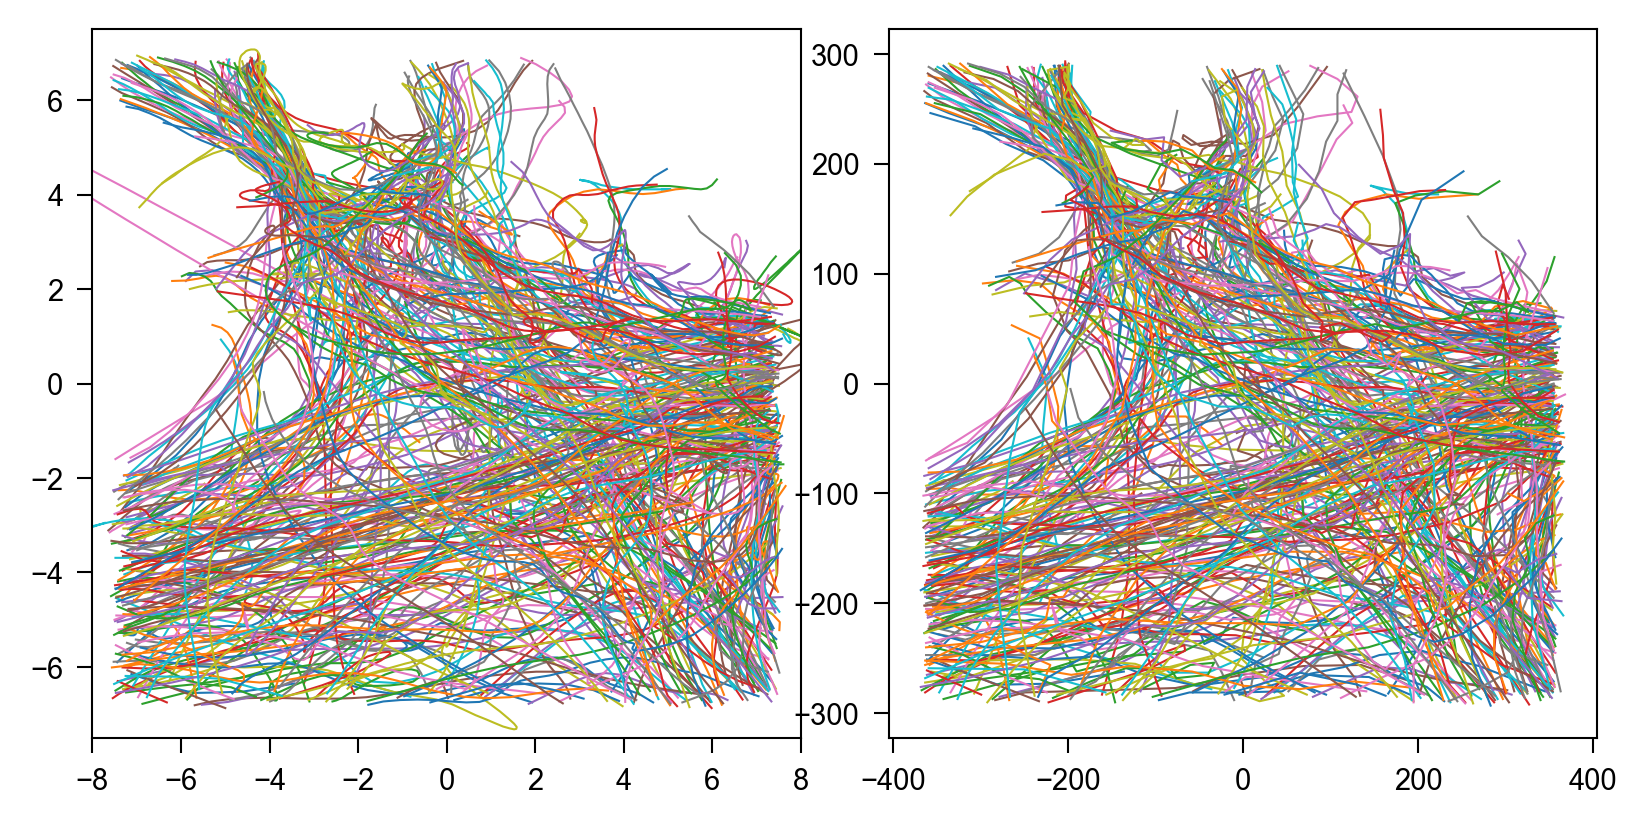

In [20]:
from src.utils.plot import get_fig, plt, sns

fi, fig, axes = get_fig(1, 2, AW=6, AH=6)

for id, group in df_trajnet.groupby('id'):
    axes[0].plot(group['x'], group['y'])
    axes[0].set_xlim(-8., 8.)
    axes[0].set_ylim(-7.5, 7.5)

for id, group in df_raw.groupby('id'):
    axes[1].plot(group['x'], group['y'])

fig.savefig('test.svg')

In [10]:
df_raw

,x,y,f,direction,id,type
0,174.0,-131.0,0,91.974945,0,pedestrian
1,116.0,-139.0,27,96.340179,0,pedestrian
2,35.0,-148.0,65,98.488953,0,pedestrian
3,-32.0,-158.0,100,97.829071,0,pedestrian
4,-112.0,-169.0,140,95.253815,0,pedestrian
...,...,...,...,...,...,...
6168,188.0,92.0,3624,-147.994617,414,pedestrian
6169,208.0,60.0,3653,-122.152294,414,pedestrian
6170,243.0,38.0,3676,-99.462326,414,pedestrian
6171,297.0,29.0,3703,-111.161263,414,pedestrian
